In [1]:
# ==============================
# STEP 0: Setup Kaggle API
# ==============================
import json
import os

kaggle_dict = {
    "username": "Sathya Mozhi",  # your Kaggle username
    "key": "KGAT_a441b02dfc006e7ccb28cb7260013171"                     # your API key
}

with open("kaggle.json", "w") as file:
    json.dump(kaggle_dict, file)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download Mushroom dataset
!kaggle datasets download -d uciml/mushroom-classification
!unzip -o mushroom-classification.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/mushroom-classification
License(s): CC0-1.0
  0% 0.00/34.2k [00:00<?, ?B/s]
100% 34.2k/34.2k [00:00<00:00, 15.0MB/s]
Archive:  mushroom-classification.zip
  inflating: mushrooms.csv           


In [2]:
# ==============================
# STEP 1: Import libraries
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [3]:
# ==============================
# STEP 2: Load CSV dynamically
# ==============================
csv_files = [f for f in os.listdir() if f.endswith(".csv")]
if not csv_files:
    raise FileNotFoundError("No CSV file found. Check Kaggle download/unzip.")
df = pd.read_csv(csv_files[0])
print("Loaded CSV file:", csv_files[0])
print(df.head())
print("\nColumns:", df.columns)

Loaded CSV file: mushrooms.csv
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w  

In [4]:
# ==============================
# STEP 3: Handle missing values
# ==============================
# Some mushroom datasets use '?' for missing
df.replace('?', pd.NA, inplace=True)

# Fill missing categorical columns with mode
categorical_cols = df.columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check missing values
print("\nMissing values per column:\n", df.isna().sum())


Missing values per column:
 class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


In [5]:
# ==============================
# STEP 4: Define features & target
# ==============================
# 'class' column: edible = 'e', poisonous = 'p'
y = df['class'].apply(lambda x: 1 if x=='p' else 0)  # 1 = poisonous, 0 = edible
X = df.drop('class', axis=1)

# Convert all categorical columns to numeric
X = pd.get_dummies(X, columns=X.columns, drop_first=True)
print("Features after encoding (first 5 rows):")
print(X.head())

Features after encoding (first 5 rows):
   cap-shape_c  cap-shape_f  cap-shape_k  cap-shape_s  cap-shape_x  \
0        False        False        False        False         True   
1        False        False        False        False         True   
2        False        False        False        False        False   
3        False        False        False        False         True   
4        False        False        False        False         True   

   cap-surface_g  cap-surface_s  cap-surface_y  cap-color_c  cap-color_e  ...  \
0          False           True          False        False        False  ...   
1          False           True          False        False        False  ...   
2          False           True          False        False        False  ...   
3          False          False           True        False        False  ...   
4          False           True          False        False        False  ...   

   population_n  population_s  population_v  populat

In [6]:
# ==============================
# STEP 5: Train-test split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# ==============================
# STEP 6: Train Decision Tree
# ==============================
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)

# Predict
y_pred = dt.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Decision Tree Accuracy:", acc)
print("Confusion Matrix:\n", cm)

Decision Tree Accuracy: 0.9963076923076923
Confusion Matrix:
 [[837   6]
 [  0 782]]


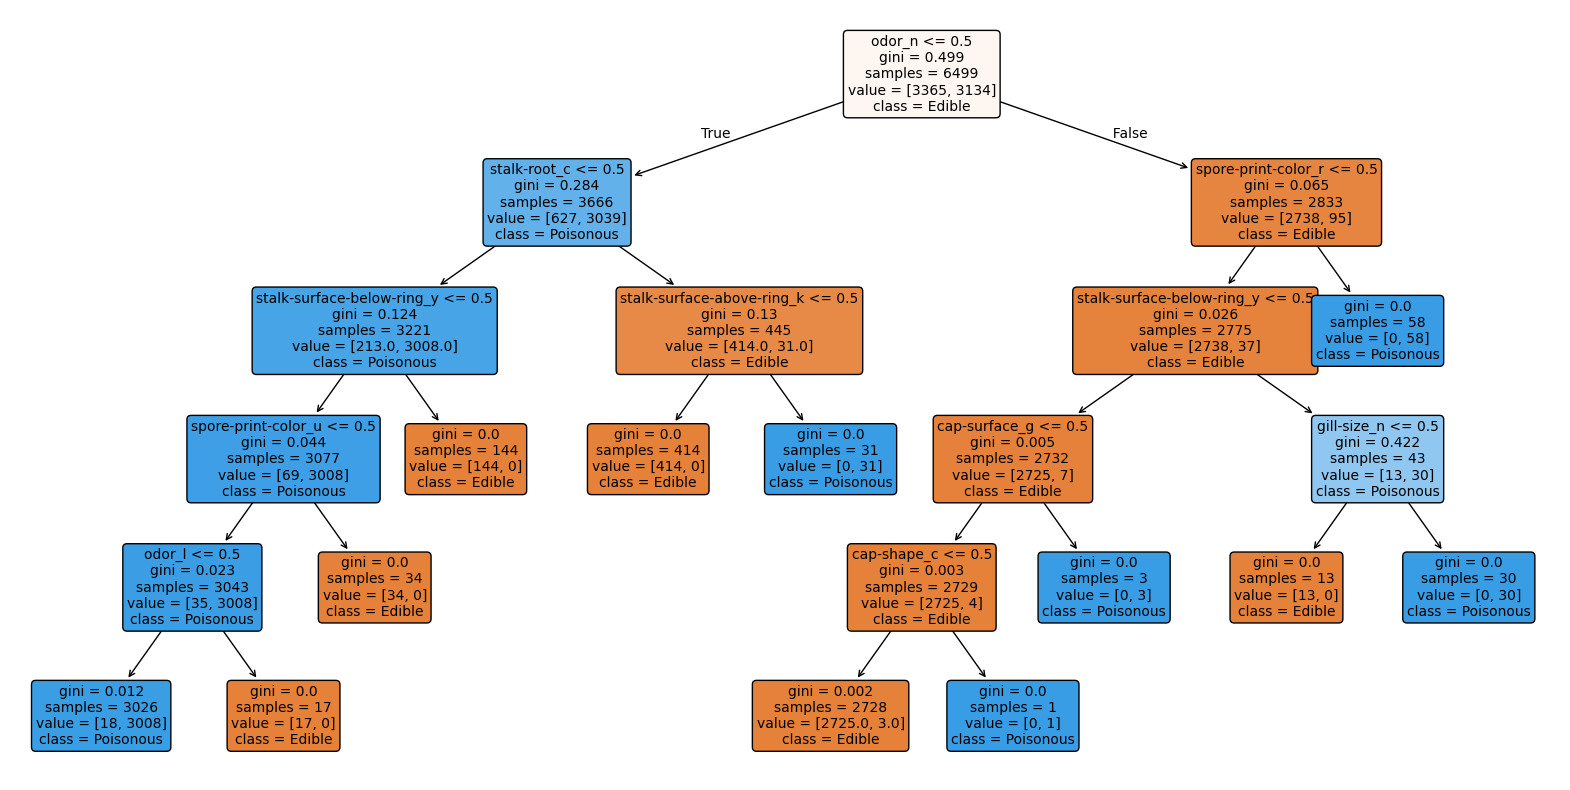

In [8]:
# ==============================
# STEP 7: Visualize Decision Tree
# ==============================
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=["Edible","Poisonous"],
          filled=True, rounded=True, fontsize=10)
plt.show()

In [9]:
# ==============================
# STEP 8: Predict new mushroom
# ==============================
# Example new mushroom input (must include all one-hot columns)
new_input = pd.DataFrame([{
    'cap-shape_b': 0, 'cap-shape_c': 0, 'cap-shape_f': 0, 'cap-shape_k': 0, 'cap-shape_s': 1,
    'cap-surface_f': 0, 'cap-surface_g': 1, 'cap-surface_s': 0, 'cap-surface_y': 0,
    'cap-color_b': 0, 'cap-color_c': 1, 'cap-color_e': 0, 'cap-color_g': 0, 'cap-color_n': 0, 'cap-color_p': 0,
    # ... you need all one-hot encoded columns
}])

# Align with training features
new_input = new_input.reindex(columns=X.columns, fill_value=0)

# Predict
prediction = dt.predict(new_input)
print("Prediction for new mushroom:", "Poisonous" if prediction[0]==1 else "Edible")

Prediction for new mushroom: Poisonous
